# Main Figure Revision Sandbox

This notebook is a separate workspace for the requested figure edits without changing `make_main_figures_outline_v2.ipynb`.

Revision targets captured here:

- Figure 2: grouped PCA plus repeated RF separability violin panels by dataset.
- Figure 4: replace pairwise correlation heatmaps with Graphical Lasso conditional-dependency networks and partial-correlation discrepancy summaries.
- Figure 5: keep the existing noise plot direction.
- Figure 6: combine HIV, breast cancer, and diabetes reverse-ablation curves into one figure.
- Figure 1 schematic: source appears to be Matplotlib code, not a PowerPoint/Keynote file or GPT image. See the final schematic notes cell for editable options.


## Load Shared Definitions

This cell imports definitions from the outline notebook without running the expensive plotting/compute calls at the bottom of those cells. It also forces `RUN_MODE = "preview"` by default for quick iteration. Switch `REVISION_RUN_MODE` to `"final"` when you want manuscript-quality repeated runs.


Repository root: c:\Users\tonyt\Desktop\distinguishable_data
Run mode: final | CVAE_EPOCHS=200, AUC_REPEATS=50, TSTR_REPEATS=20, ABLATION_REPEATS=20, NOISE_REPEATS=5
[figure4] HIV - Bootstrap
[figure4] HIV - Column-wise
[figure4] HIV - GMM
[figure4] HIV - CVAE
Epoch    1 | train loss=59.4345 recon=59.3622 kl=0.1446 | val loss=78.4132 recon=78.3381 kl=0.1501
Epoch   10 | train loss=55.0814 recon=54.5651 kl=1.0327 | val loss=75.1556 recon=74.4211 kl=1.4690
Epoch   20 | train loss=49.5437 recon=46.3646 kl=6.3583 | val loss=59.7132 recon=57.2741 kl=4.8782
Epoch   30 | train loss=37.0336 recon=35.2526 kl=3.5620 | val loss=55.3492 recon=52.8178 kl=5.0628
Epoch   40 | train loss=35.7443 recon=31.5312 kl=8.4264 | val loss=53.4445 recon=48.9844 kl=8.9201
Epoch   50 | train loss=33.3516 recon=29.9936 kl=6.7162 | val loss=48.4559 recon=44.0604 kl=8.7910
Epoch   60 | train loss=33.5782 recon=29.7126 kl=7.7312 | val loss=47.5115 recon=43.3358 kl=8.3514
Epoch   70 | train loss=25.4368 recon=21.6556 

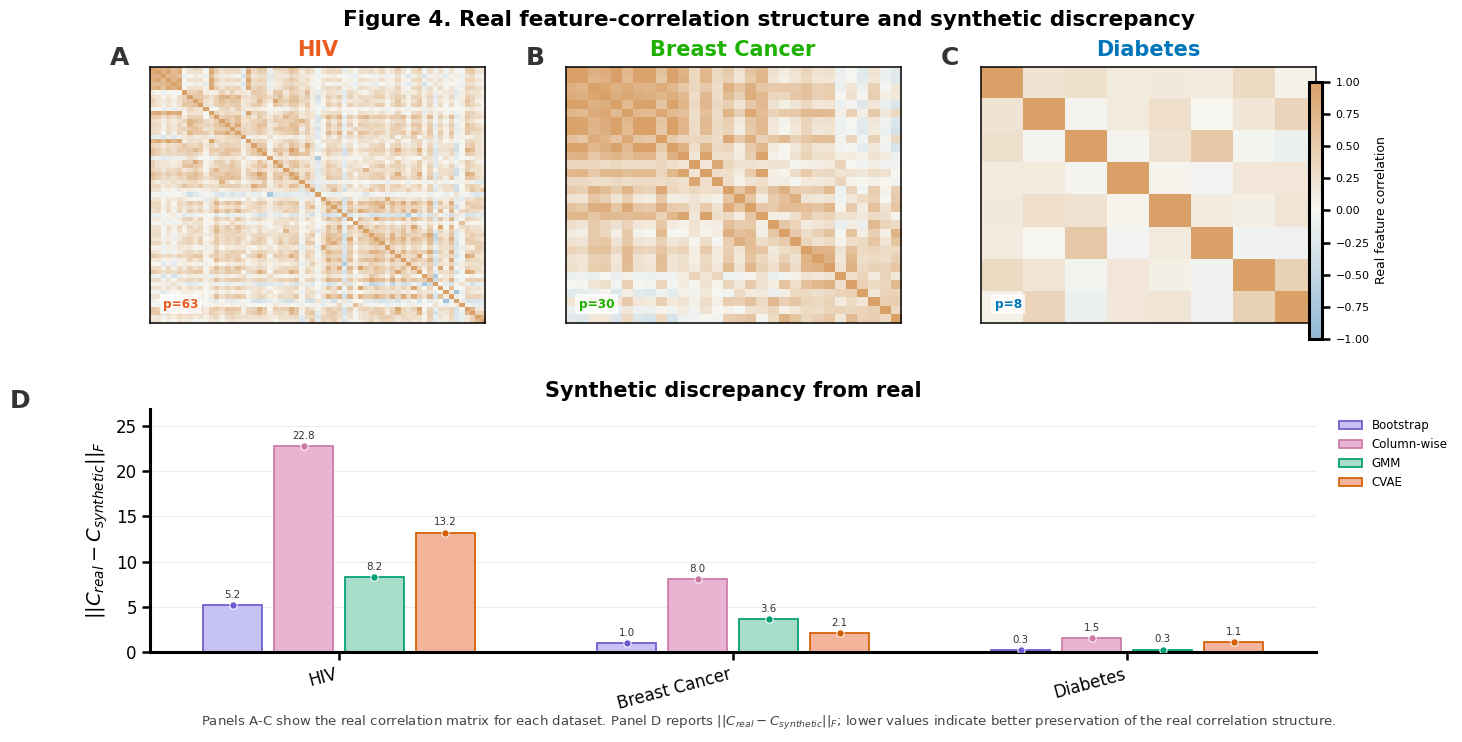

Loaded outline definitions from C:\Users\tonyt\Desktop\distinguishable_data\data_synthesis\notebooks\make_main_figures_outline_v2.ipynb
Revision run mode: final; CVAE_EPOCHS=200; AUC_REPEATS=50; ABLATION_REPEATS=20
         dataset  samples  features  class_0  class_1
0            HIV       91        63       23       68
1  Breast Cancer      569        30      212      357
2       Diabetes      768         8      500      268


In [40]:
from pathlib import Path
import json
import pickle
import re

REVISION_RUN_MODE = "final" 
OUTLINE_NOTEBOOK = Path("data_synthesis/notebooks/make_main_figures_outline_v2.ipynb")


def _find_repo_root():
    here = Path.cwd().resolve()
    candidates = [here, *here.parents]
    for candidate in candidates:
        if (candidate / OUTLINE_NOTEBOOK).exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {OUTLINE_NOTEBOOK} from {here}. "
        "Run this notebook from the repository or update OUTLINE_NOTEBOOK."
    )


repo_root = _find_repo_root()
outline_path = repo_root / OUTLINE_NOTEBOOK
CACHE_DIR = repo_root / "data_synthesis" / "notebooks" / "revision_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)


def _trim_source(src, stop_patterns):
    lines = src.splitlines()
    kept = []
    for line in lines:
        if any(re.search(pattern, line) for pattern in stop_patterns):
            break
        kept.append(line)
    return "\n".join(kept) + "\n"


def _pick_code_cell(code_cells, startswith):
    for src in code_cells:
        if src.lstrip().startswith(startswith):
            return src
    raise KeyError(f"Could not find outline code cell starting with: {startswith}")


def _find_code_cell(code_cells, text):
    for src in code_cells:
        if text in src:
            return src
    raise KeyError(f"Could not find outline code cell containing: {text}")


def load_outline_definitions(run_mode=REVISION_RUN_MODE):
    nb = json.loads(outline_path.read_text(encoding="utf-8"))
    code_cells = ["".join(cell.get("source", [])) for cell in nb["cells"] if cell.get("cell_type") == "code"]

    selected = []
    setup = _pick_code_cell(code_cells, "from pathlib import Path")
    selected.append(setup.replace('RUN_MODE = "final"', f'RUN_MODE = "{run_mode}"'))
    selected.append(_pick_code_cell(code_cells, "def _to_numpy_X"))
    selected.append(_trim_source(_pick_code_cell(code_cells, "def plot_figure2_cvae_pca"), [r"^plot_figure2_cvae_pca\("]))
    selected.append(_trim_source(_pick_code_cell(code_cells, "def one_run_origin_auc"), [r"^auc_runs\s*="]))
    selected.append(_trim_source(_pick_code_cell(code_cells, "def mean_kld_by_feature"), [r"^metric_table\s*="]))
    selected.append(_trim_source(_pick_code_cell(code_cells, "def feature_group"), [r"^plot_figure4_structure_panel\("]))
    selected.append(_trim_source(_pick_code_cell(code_cells, "def rank_discriminating_features"), [r"^ablation_df\s*="]))
    selected.append(_trim_source(_find_code_cell(code_cells, "def plot_figure6_ablation_ac"), [r"^if \"ablation_df\" in globals\(\):"]))

    g = globals()
    for src in selected:
        exec(compile(src, str(outline_path), "exec"), g)

    # The imported setup cell defines its own repo_root based on the kernel cwd.
    # Restore the robust root found above so later export/cache paths are stable.
    g["repo_root"] = repo_root


load_outline_definitions()
print(f"Loaded outline definitions from {outline_path}")
print(f"Revision run mode: {RUN_MODE}; CVAE_EPOCHS={CVAE_EPOCHS}; AUC_REPEATS={AUC_REPEATS}; ABLATION_REPEATS={ABLATION_REPEATS}")
print(summary)


## Cached Compute Helpers

These wrappers avoid recomputing repeated RF probes, Graphical Lasso structure summaries, and reverse ablation every time the notebook is opened. Set `force=True` in any helper call to regenerate.


In [41]:
def _cache_path(name):
    return CACHE_DIR / f"{name}_{RUN_MODE}.pkl"


def _read_cache(name):
    path = _cache_path(name)
    if path.exists():
        with path.open("rb") as f:
            return pickle.load(f)
    return None


def _write_cache(name, obj):
    path = _cache_path(name)
    with path.open("wb") as f:
        pickle.dump(obj, f)
    return obj


def get_auc_runs(force=False):
    cached = None if force else _read_cache("auc_runs")
    if cached is not None:
        return cached
    return _write_cache("auc_runs", compute_auc_run_table(datasets))


def get_metric_table(force=False):
    cached = None if force else _read_cache("metric_table")
    if cached is not None:
        return cached
    auc_runs = get_auc_runs(force=force)
    return _write_cache("metric_table", build_metric_table(datasets, auc_runs))


def get_reverse_ablation(force=False):
    cached = None if force else _read_cache("ablation_df")
    if cached is not None:
        return cached
    return _write_cache("ablation_df", compute_reverse_ablation(datasets))


## Figure 2 Decision Note

The boxplot version is omitted here. Figure 2 uses the PCA panels plus the repeated RF separability violin panels, because the violins show the full repeated-run distribution while keeping the dataset-level story compact.

The default is a grouped 6-panel Figure 2, arranged by dataset columns and labeled by plot-type rows:

- HIV column: PCA geometry + repeated RF separability violin.
- Breast Cancer column: PCA geometry + repeated RF separability violin.
- Diabetes column: PCA geometry + repeated RF separability violin.

Vertical dividers separate the dataset groups so each PCA/separability pair reads as one unit. Panels A-C show PCA geometry; panels D-F show repeated RF separability.


In [104]:
def _plot_pca_panel(ax, ds, panel, seed=SEED, cvae_epochs=CVAE_EPOCHS):
    data = datasets[ds]
    X_real = np.asarray(data["X"], dtype=np.float32)
    X_syn, _ = sample_synthetic(ds, data, "CVAE", seed=seed, cvae_epochs=cvae_epochs)
    Xr, Xs = standardize_pair(X_real, X_syn)
    pca = PCA(n_components=2, random_state=seed).fit(Xr)
    Zr = pca.transform(Xr)
    Zs = pca.transform(Xs)
    rng = np.random.default_rng(seed)
    Zs_plot = Zs[rng.choice(len(Zs), size=700, replace=False)] if len(Zs) > 700 else Zs

    ax.scatter(Zr[:, 0], Zr[:, 1], s=8, marker="o", facecolors="none", alpha=0.58,
               edgecolors="#8A8A8A", linewidths=0.55, label="Real data")
    ax.scatter(Zs_plot[:, 0], Zs_plot[:, 1], s=8, marker="o", color=DATASET_COLORS[ds], alpha=0.74,
               edgecolors="none", label="CVAE synthetic data")
    add_confidence_ellipse(ax, Zr, "#8A8A8A", linewidth=1.8)
    add_confidence_ellipse(ax, Zs, DATASET_COLORS[ds], linewidth=2.0)

    all_z = np.vstack([Zr, Zs_plot])
    x_min, x_max = np.nanmin(all_z[:, 0]), np.nanmax(all_z[:, 0])
    y_min, y_max = np.nanmin(all_z[:, 1]), np.nanmax(all_z[:, 1])
    ax.set_xlim(x_min - (x_max - x_min) * 0.24, x_max + (x_max - x_min) * 0.24)
    ax.set_ylim(y_min - (y_max - y_min) * 0.24, y_max + (y_max - y_min) * 0.24)

    ev = pca.explained_variance_ratio_
    ax.set_title(ds, color=DATASET_COLORS[ds], weight="semibold", pad=8)
    ax.set_xlabel(f"PC1 ({ev[0] * 100:.1f}%)")
    ax.set_ylabel(f"PC2 ({ev[1] * 100:.1f}%)")
    ax.text(0.045, 0.055, f"n={len(data['y'])}, p={X_real.shape[1]}", transform=ax.transAxes,
            color=DATASET_COLORS[ds], fontsize=8.5, weight="bold", ha="left", va="bottom")
    ax.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="#BDBDBD",
              framealpha=0.92, fontsize=7.8, handlelength=1.2, borderpad=0.35,
              labelspacing=0.25, handletextpad=0.35)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)
    ax.tick_params(labelsize=8.5, width=1.2, length=4)
    add_panel_label(ax, panel)


def _plot_auc_violin_panel(ax, auc_runs, ds, panel):
    sub = auc_runs[auc_runs["dataset"] == ds]
    positions = np.arange(len(METHOD_ORDER))
    values = [sub[sub["method"] == method]["separability_auc"].dropna().to_numpy() for method in METHOD_ORDER]

    violins = ax.violinplot(values, positions=positions, widths=0.72, showmeans=False, showmedians=False, showextrema=False)
    for body, method in zip(violins["bodies"], METHOD_ORDER):
        body.set_facecolor(METHOD_PASTELS[method])
        body.set_edgecolor(METHOD_COLORS[method])
        body.set_linewidth(1.45)
        body.set_alpha(0.95)

    for pos, vals, method in zip(positions, values, METHOD_ORDER):
        vals = np.asarray(vals, dtype=float)
        if len(vals) == 0:
            continue
        q1, med, q3 = np.percentile(vals, [25, 50, 75])
        mean = np.mean(vals)
        ax.vlines(pos, q1, q3, color=METHOD_COLORS[method], linewidth=3.0, alpha=0.92)
        ax.scatter(pos, med, s=28, color="white", edgecolor=METHOD_COLORS[method], linewidth=1.3, zorder=4)
        ax.scatter(pos, mean, s=22, color=METHOD_COLORS[method], edgecolor="white", linewidth=0.7, zorder=5)

    ax.axhline(0.5, color="#777777", linestyle="--", linewidth=1.2)
    ax.set_xticks(positions)
    ax.set_xticklabels(METHOD_ORDER,fontsize=8.5)
    ax.set_ylabel("AUC")
    # Match PCA-panel style
    clean_axis(ax, grid_axis="y")

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)

    ax.tick_params(labelsize=8.5, width=1.2, length=4)
    add_panel_label(ax, panel)
def _plot_auc_line_panel(ax, auc_runs, ds, panel):
    sub = auc_runs[auc_runs["dataset"] == ds]
    means = sub.groupby("method")["separability_auc"].mean().reindex(METHOD_ORDER)
    sds = sub.groupby("method")["separability_auc"].std().reindex(METHOD_ORDER)
    x = np.arange(len(METHOD_ORDER))
    for i, method in enumerate(METHOD_ORDER):
        ax.errorbar(i, means.loc[method], yerr=sds.loc[method], marker="o", markersize=7,
                    color=METHOD_COLORS[method], capsize=4, linewidth=2.0)
    ax.plot(x, means.to_numpy(), color=DATASET_COLORS[ds], linewidth=2.0, alpha=0.65)
    ax.axhline(0.5, color="#777777", linestyle="--", linewidth=1.2)
    ax.set_xticks(x)
    ax.set_xticklabels(METHOD_ORDER, rotation=25, ha="right", fontsize=8.5)
    ax.set_title(f"{ds}: mean +/- SD", color=DATASET_COLORS[ds], weight="bold", pad=8)
    ax.set_ylabel("AUC")
    clean_axis(ax, grid_axis="y")
    add_panel_label(ax, panel)


def plot_figure2_six_panel(auc_runs):
    fig, axes = plt.subplots(2, 3, figsize=(13.8, 8.2))
    panel_labels = [("A1", "A2"), ("B1", "B2"), ("C1", "C2")]

    for col, ds in enumerate(DATASET_ORDER):
        pca_ax = axes[0, col]
        sep_ax = axes[1, col]
        _plot_pca_panel(pca_ax, ds, panel_labels[col][0])
        _plot_auc_violin_panel(sep_ax, auc_runs, ds, panel_labels[col][1])

        # Use one dataset header per column, so each PCA/separability pair reads as a unit.
        pca_ax.set_title("")

    # fig.suptitle("Synthetic data geometry and separability by dataset", y=0.99, fontsize=15, weight="semibold")
    fig.subplots_adjust(left=0.065, right=0.99, top=0.83, bottom=0.10, wspace=0.34, hspace=0.38)

    for col, ds in enumerate(DATASET_ORDER):
        # Compute after subplots_adjust so the header is centered over the final column position.
        top_box = axes[0, col].get_position()
        x_center = (top_box.x0 + top_box.x1) / 2
        fig.text(
            x_center,
            0.845,
            ds,
            ha="center",
            va="bottom",
            fontsize=13.5,
            weight="bold",
            color=DATASET_COLORS[ds],
        )

    return fig


def plot_figure2_nine_panel(auc_runs):
    fig, axes = plt.subplots(3, 3, figsize=(13.8, 11.4))
    panels = list("ABCDEFGHI")
    for ax, ds, panel in zip(axes[0], DATASET_ORDER, panels[:3]):
        _plot_pca_panel(ax, ds, panel)
    for ax, ds, panel in zip(axes[1], DATASET_ORDER, panels[3:6]):
        _plot_auc_violin_panel(ax, auc_runs, ds, panel)
    for ax, ds, panel in zip(axes[2], DATASET_ORDER, panels[6:]):
        _plot_auc_line_panel(ax, auc_runs, ds, panel)
    # fig.suptitle("Figure 2. PCA geometry, separability distributions, and summary trends", y=0.99, fontsize=15, weight="semibold")
    fig.subplots_adjust(left=0.065, right=0.99, top=0.94, bottom=0.08, wspace=0.30, hspace=0.50)
    return fig


Epoch    1 | train loss=59.4345 recon=59.3622 kl=0.1446 | val loss=78.4132 recon=78.3381 kl=0.1501
Epoch   10 | train loss=55.0814 recon=54.5651 kl=1.0327 | val loss=75.1556 recon=74.4211 kl=1.4690
Epoch   20 | train loss=49.5437 recon=46.3646 kl=6.3583 | val loss=59.7132 recon=57.2741 kl=4.8782
Epoch   30 | train loss=37.0336 recon=35.2526 kl=3.5620 | val loss=55.3492 recon=52.8178 kl=5.0628
Epoch   40 | train loss=35.7443 recon=31.5312 kl=8.4264 | val loss=53.4445 recon=48.9844 kl=8.9201
Epoch   50 | train loss=33.3516 recon=29.9936 kl=6.7162 | val loss=48.4559 recon=44.0604 kl=8.7910
Epoch   60 | train loss=33.5782 recon=29.7126 kl=7.7312 | val loss=47.5115 recon=43.3358 kl=8.3514
Epoch   70 | train loss=25.4368 recon=21.6556 kl=7.5625 | val loss=49.1987 recon=44.7192 kl=8.9590
Epoch   80 | train loss=27.3788 recon=22.9788 kl=8.8000 | val loss=46.1841 recon=41.4502 kl=9.4678
Epoch   90 | train loss=26.5942 recon=21.7606 kl=9.6673 | val loss=46.5686 recon=41.9486 kl=9.2398
Epoch  100

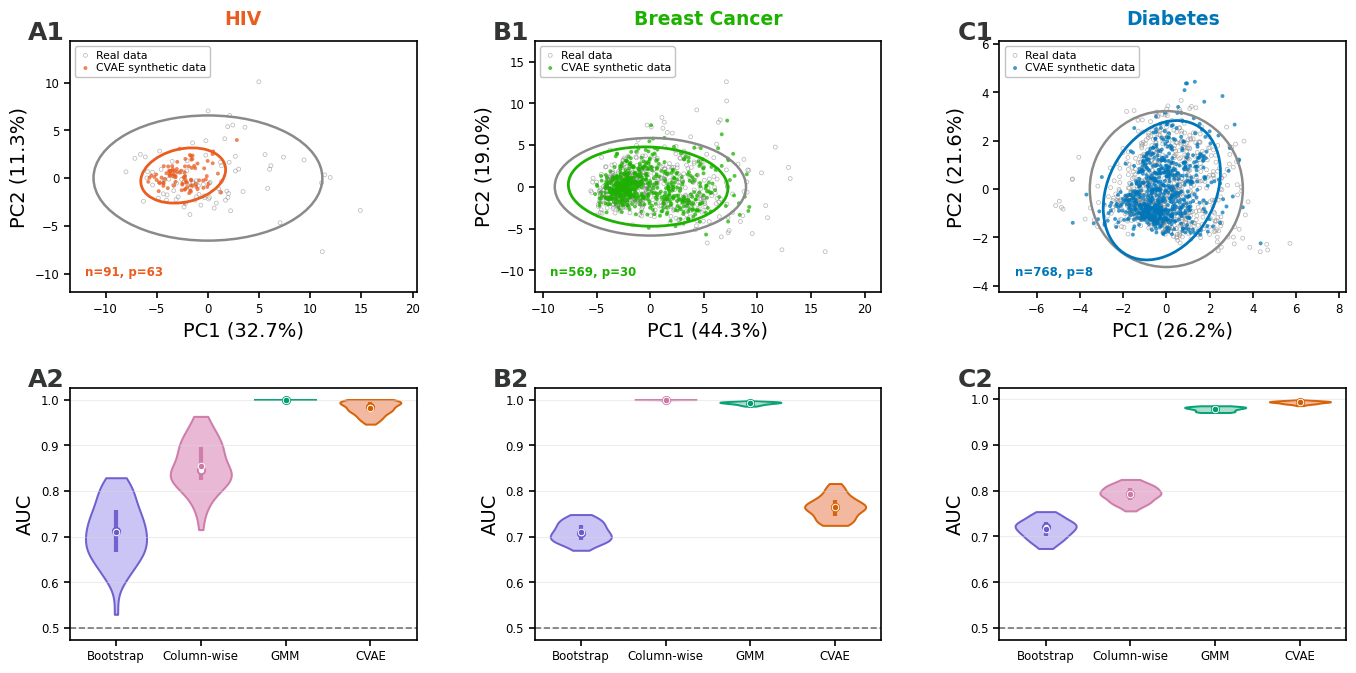

In [105]:
auc_runs = get_auc_runs(force=False)
fig2_6 = plot_figure2_six_panel(auc_runs)


## Figure 4: Synthetic Deviation from Real Conditional-Dependence Structure

Question: do synthetic datasets preserve the same conditional-dependency structure as the real dataset?

Figure 4 uses Graphical Lasso rather than ordinary pairwise correlation. Graphical Lasso estimates a sparse precision matrix, where off-diagonal entries encode conditional relationships among features:

`precision-matrix discrepancy = ||Theta_real - Theta_synthetic||_F`

Main readout:

- **A. Real HIV precision matrix**: off-diagonal real-data Graphical Lasso precision matrix after hierarchical feature ordering.
- **B. Closest synthetic precision matrix**: HIV synthetic method with the smallest Frobenius deviation from the real HIV precision matrix.
- **C. Most divergent synthetic precision matrix**: HIV synthetic method with the largest Frobenius deviation from the real HIV precision matrix.
- **D. Deviation from closest synthetic**: entrywise absolute deviation from the real HIV precision matrix.
- **E. Deviation from most divergent synthetic**: entrywise absolute deviation from the real HIV precision matrix.
- **F. Frobenius discrepancy**: all datasets and methods summarized quantitatively. Lower is better.

Panels A-C use one shared diverging precision scale, and Panels D-E use one shared sequential difference scale.

In [44]:
import importlib
import src.figure4_neighborhood as figure4_neighborhood

figure4_neighborhood = importlib.reload(figure4_neighborhood)

from src.figure4_neighborhood import (
    fit_glasso_precision,
    precision_to_partial_corr,
    get_edge_set,
    choose_anchor_feature,
    get_anchor_neighborhood_edges,
    plot_overlap_neighborhood,
    compute_edge_recovery,
    compute_synthetic_only_rate,
    compute_frobenius_deviation,
    plot_summary_metrics,
    plot_figure4_neighborhood_overlap,
    plot_figure4_edge_overlap_matrix,
    plot_figure4_edge_status_matrices,
)


EXPORT_DIR = globals().get("EXPORT_DIR", repo_root / "data_synthesis" / "notebooks" / "revision_exports")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE4_OUTPUT = EXPORT_DIR / "figure_4_edge_status_matrices.png"
FIGURE4_ALPHAS = {"HIV": 0.504, "Breast Cancer": 0.502, "Diabetes": 0.0159}


def _build_notebook_precision_inputs(seed=SEED, cvae_epochs=CVAE_EPOCHS):
    real_data = {}
    synthetic_data = {}
    feature_name_map = {}
    for ds in DATASET_ORDER:
        data = datasets[ds]
        real_data[ds] = np.asarray(data["X"], dtype=np.float64)
        feature_name_map[ds] = list(data.get("feature_names", [f"f{i}" for i in range(real_data[ds].shape[1])]))
        synthetic_data[ds] = {}
        for method in METHOD_ORDER:
            X_syn, _ = sample_synthetic(ds, data, method, seed=seed, cvae_epochs=cvae_epochs)
            synthetic_data[ds][method] = np.asarray(X_syn, dtype=np.float64)
    return real_data, synthetic_data, feature_name_map


def plot_figure4_correlation_change(corr_summary=None, exemplar_ds="HIV", anchor_feature=None, threshold=1e-7):
    real_data, synthetic_data, feature_name_map = _build_notebook_precision_inputs(
        seed=SEED, cvae_epochs=CVAE_EPOCHS
    )
    return plot_figure4_edge_status_matrices(
        real_data=real_data,
        synthetic_data=synthetic_data,
        feature_names=feature_name_map,
        alphas=FIGURE4_ALPHAS,
        dataset_order=DATASET_ORDER,
        method_order=METHOD_ORDER,
        exemplar_ds=exemplar_ds,
        threshold=threshold,
        save_path=FIGURE4_OUTPUT,
    )


Epoch    1 | train loss=59.4345 recon=59.3622 kl=0.1446 | val loss=78.4132 recon=78.3381 kl=0.1501
Epoch   10 | train loss=55.0814 recon=54.5651 kl=1.0327 | val loss=75.1556 recon=74.4211 kl=1.4690
Epoch   20 | train loss=49.5437 recon=46.3646 kl=6.3583 | val loss=59.7132 recon=57.2741 kl=4.8782
Epoch   30 | train loss=37.0336 recon=35.2526 kl=3.5620 | val loss=55.3492 recon=52.8178 kl=5.0628
Epoch   40 | train loss=35.7443 recon=31.5312 kl=8.4264 | val loss=53.4445 recon=48.9844 kl=8.9201
Epoch   50 | train loss=33.3516 recon=29.9936 kl=6.7162 | val loss=48.4559 recon=44.0604 kl=8.7910
Epoch   60 | train loss=33.5782 recon=29.7126 kl=7.7312 | val loss=47.5115 recon=43.3358 kl=8.3514
Epoch   70 | train loss=25.4368 recon=21.6556 kl=7.5625 | val loss=49.1987 recon=44.7192 kl=8.9590
Epoch   80 | train loss=27.3788 recon=22.9788 kl=8.8000 | val loss=46.1841 recon=41.4502 kl=9.4678
Epoch   90 | train loss=26.5942 recon=21.7606 kl=9.6673 | val loss=46.5686 recon=41.9486 kl=9.2398
Epoch  100

c:\Users\tonyt\Desktop\distinguishable_data\.venv\Lib\site-packages\sklearn\covariance\_graph_lasso.py:199: ConvergenceWarning: graphical_lasso: did not converge after 1000 iteration: dual gap: -1.299e-04
  warnings.warn(


,dataset,method,frobenius_deviation,edge_recovery,synthetic_only_rate,n_real_edges,n_synthetic_edges
4,Breast Cancer,Bootstrap,0.378561,0.927835,0.052632,97,95
7,Breast Cancer,CVAE,0.750652,0.948454,0.192982,97,114
5,Breast Cancer,Column-wise,2.412744,0.278351,0.100000,97,30
6,Breast Cancer,GMM,0.922085,0.793814,0.012821,97,78
8,Diabetes,Bootstrap,0.370135,1.000000,0.125000,21,24
11,Diabetes,CVAE,2.851276,0.952381,0.200000,21,25
9,Diabetes,Column-wise,1.662236,0.666667,0.263158,21,19
10,Diabetes,GMM,0.283061,0.952381,0.200000,21,25
0,HIV,Bootstrap,1.183656,0.811828,0.209424,186,191
3,HIV,CVAE,2.508329,0.741935,0.588060,186,335


,matrix_index,feature_original_index,feature_name
0,1,1,spikeProduction_D1D2
1,2,2,spikeDecay_D1D2
2,3,51,V8_IL2
3,4,52,V9_IL2
4,5,56,Il2_production
...,...,...,...
58,59,8,RBDDecay_D3
59,60,3,spikeProduction_D3
60,61,4,spikeDecay_D3
61,62,5,RBDProduction_D1D2


Saved Figure 4 to c:\Users\tonyt\Desktop\distinguishable_data\data_synthesis\notebooks\revision_exports\figure_4_edge_status_matrices.png


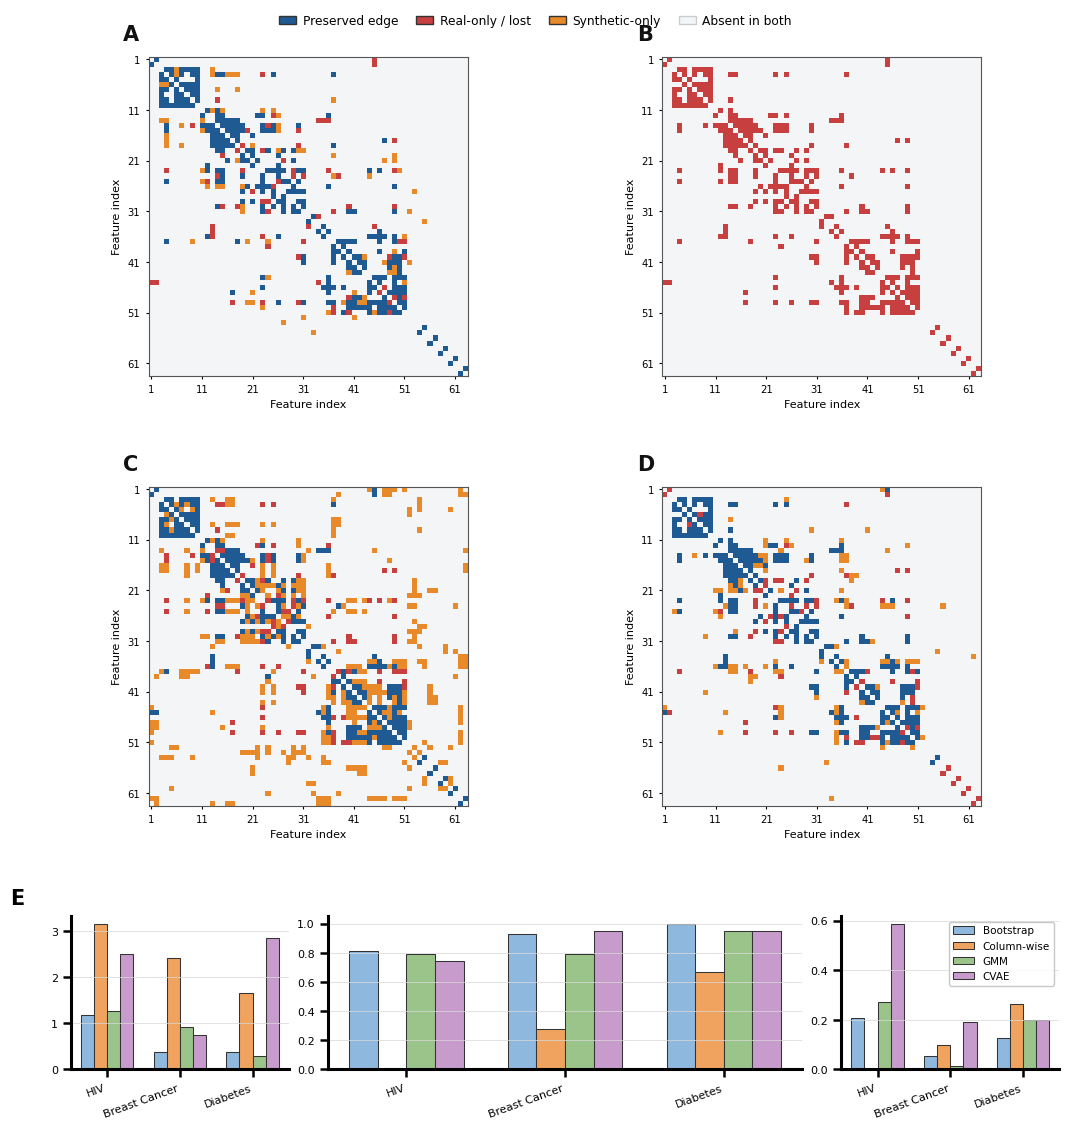

In [45]:
fig4_result = plot_figure4_correlation_change()
corr_summary = fig4_result.metrics

display(corr_summary.sort_values(["dataset", "method"]))
display(fig4_result.feature_index)
print(f"Saved Figure 4 to {FIGURE4_OUTPUT}")


## Figure 5: Noise Sensitivity

Repeated here from the outline notebook so this revision notebook can generate the full figure set in one place. Synthetic data are perturbed by increasing Gaussian noise, and RF real-vs-synthetic separability is recomputed across datasets and generators.


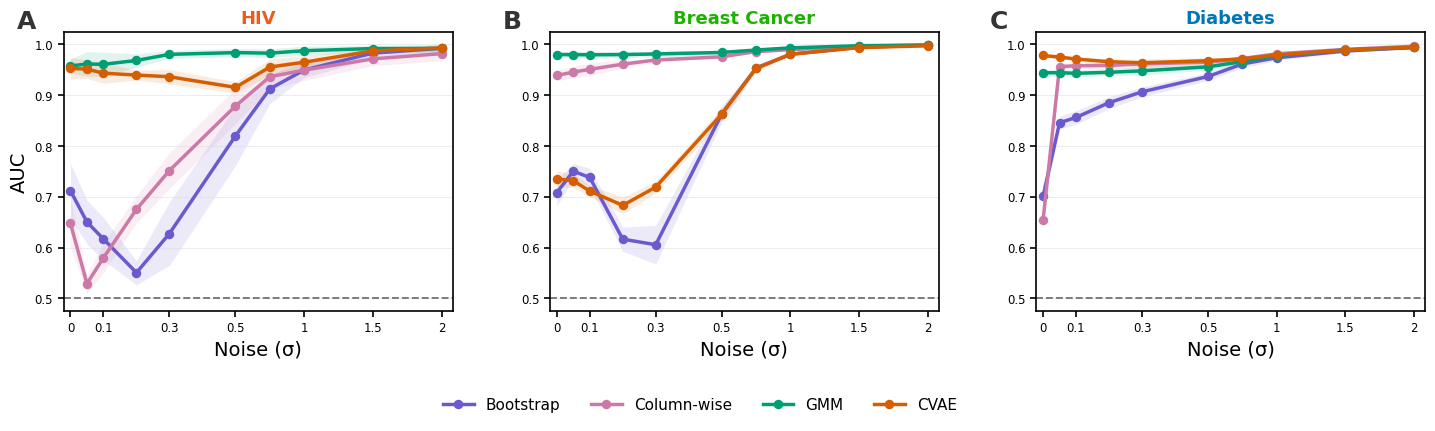

In [106]:
def stratified_subsample(X, y, n0, n1, seed=SEED):
    rng = np.random.default_rng(seed)
    idx0 = np.where(y == 0)[0]
    idx1 = np.where(y == 1)[0]
    take0 = rng.choice(idx0, size=max(1, min(n0, len(idx0))), replace=False)
    take1 = rng.choice(idx1, size=max(1, min(n1, len(idx1))), replace=False)
    idx = np.r_[take0, take1]
    rng.shuffle(idx)
    return X[idx], y[idx]


def compute_noise_sensitivity(datasets, seed=SEED, repeats=NOISE_REPEATS, sigmas=PROBE_SIGMAS, frac=NOISE_FRAC, cvae_epochs=CVAE_EPOCHS):
    rows = []
    for ds in DATASET_ORDER:
        data = datasets[ds]
        X = np.asarray(data["X"], dtype=np.float32)
        y = np.asarray(data["y"], dtype=int)
        n0 = max(2, int((y == 0).sum() * frac))
        n1 = max(2, int((y == 1).sum() * frac))
        X_sub, y_sub = stratified_subsample(X, y, n0, n1, seed=seed)
        stds = X_sub.std(axis=0)
        stds = np.where(stds == 0, 1.0, stds)
        feat_cols = [f"f{i}" for i in range(X_sub.shape[1])]
        print(f"[noise] training CVAE for {ds}")
        state = train_cvae(X_sub, y_sub, cfg=Config(seed=seed, epochs=cvae_epochs, batch_size=32), verbose=False)
        generators = {
            "Bootstrap": lambda s: sample_bootstrap(X_sub, y_sub, n0, n1, seed=s),
            "Column-wise": lambda s: sample_columnwise(X_sub, y_sub, n0, n1, seed=s),
            "GMM": lambda s: sample_gmm(X_sub, y_sub, n0, n1, seed=s),
            "CVAE": lambda s: sample_trained_cvae(state, n0, n1, seed=s),
        }
        for method, gen in generators.items():
            for sigma in sigmas:
                vals = []
                for r in range(repeats):
                    rep_seed = seed + r
                    X_syn, _ = gen(rep_seed)
                    X_syn = np.asarray(X_syn, dtype=np.float64)
                    if sigma > 0:
                        rng = np.random.default_rng(rep_seed + 500)
                        X_syn = X_syn + rng.standard_normal(X_syn.shape) * stds * sigma
                    real_df = pd.DataFrame(X_sub, columns=feat_cols)
                    real_df["target"] = 1
                    syn_df = pd.DataFrame(X_syn, columns=feat_cols)
                    syn_df["target"] = 0
                    combined = pd.concat([real_df, syn_df], ignore_index=True)
                    avg, _, _ = RFWrapper.from_combined(combined)
                    vals.append(max(float(avg), 1.0 - float(avg)))
                rows.append({"dataset": ds, "method": method, "sigma": sigma,
                             "sep_mean": float(np.mean(vals)), "sep_sd": float(np.std(vals)),
                             "sep_values": [float(v) for v in vals]})
                print(f"[noise] {ds} {method} sigma={sigma}")
    return pd.DataFrame(rows)


def get_noise_sensitivity(force=False):
    cached = None if force else _read_cache("noise_df")
    if cached is not None:
        return cached
    result = compute_noise_sensitivity(datasets)
    return _write_cache("noise_df", result)


def noise_axis_position(sigma, expand_until=0.5, expand_factor=2.4):
    sigma = np.asarray(sigma, dtype=float)
    return np.where(sigma <= expand_until, sigma * expand_factor, expand_until * expand_factor + (sigma - expand_until))


def plot_figure5_noise(noise_df):
    fig, axes = plt.subplots(1, 3, figsize=(14.8, 4.9), sharey=True, constrained_layout=False)
    legend_handles = []
    tick_sigmas = np.asarray(sorted(noise_df["sigma"].unique()), dtype=float)
    tick_sigmas = tick_sigmas[np.isin(tick_sigmas, [0, 0.1, 0.3, 0.5, 1.0, 1.5, 2.0])]
    tick_positions = noise_axis_position(tick_sigmas)
    tick_labels = [f"{s:g}" for s in tick_sigmas]

    for ax, ds, panel in zip(axes, DATASET_ORDER, ["A", "B", "C"]):
        sub = noise_df[noise_df["dataset"] == ds]
        for method in METHOD_ORDER:
            m = sub[sub["method"] == method].sort_values("sigma")
            if m.empty:
                continue
            x = noise_axis_position(m["sigma"])
            line, = ax.plot(x, m["sep_mean"], marker="o", color=METHOD_COLORS[method], label=method,
                            linewidth=2.5, markersize=5.8)
            ax.fill_between(x, m["sep_mean"] - m["sep_sd"], m["sep_mean"] + m["sep_sd"],
                            color=METHOD_COLORS[method], alpha=0.12, linewidth=0)
            if ax is axes[0]:
                legend_handles.append(line)
        ax.axhline(0.5, color="#777777", linestyle="--", linewidth=1.35)

        ax.set_title(ds, color=DATASET_COLORS[ds], weight="semibold", fontsize=13)
        ax.set_xlabel("Noise (σ)")
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels)
        ax.set_xlim(noise_axis_position(0) - 0.05, noise_axis_position(float(np.max(noise_df["sigma"]))) + 0.08)
        clean_axis(ax, grid_axis="y")

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.2)

        ax.tick_params(labelsize=8.5, width=1.2, length=4, labelleft=True)

        add_panel_label(ax, panel)
    axes[0].set_ylabel("AUC")
    fig.legend(legend_handles, METHOD_ORDER, loc="lower center", bbox_to_anchor=(0.5, 0.01), ncol=len(METHOD_ORDER),
               frameon=True, facecolor="white", edgecolor="black", framealpha=0, borderpad=0.55)
    # fig.suptitle("Noise sensitivity", y=0.98, fontsize=15, weight="semibold")
    fig.subplots_adjust(left=0.07, right=0.99, top=0.82, bottom=0.25, wspace=0.25)
    return fig


noise_df = get_noise_sensitivity(force=False)
fig5_noise = plot_figure5_noise(noise_df)


## Figure 6: Single Combined Reverse-Ablation Figure

This uses the all-dataset A-C function added to the outline notebook, and keeps the x-axis as percentage of top discriminator-ranked features removed so datasets with different numbers of features are comparable.


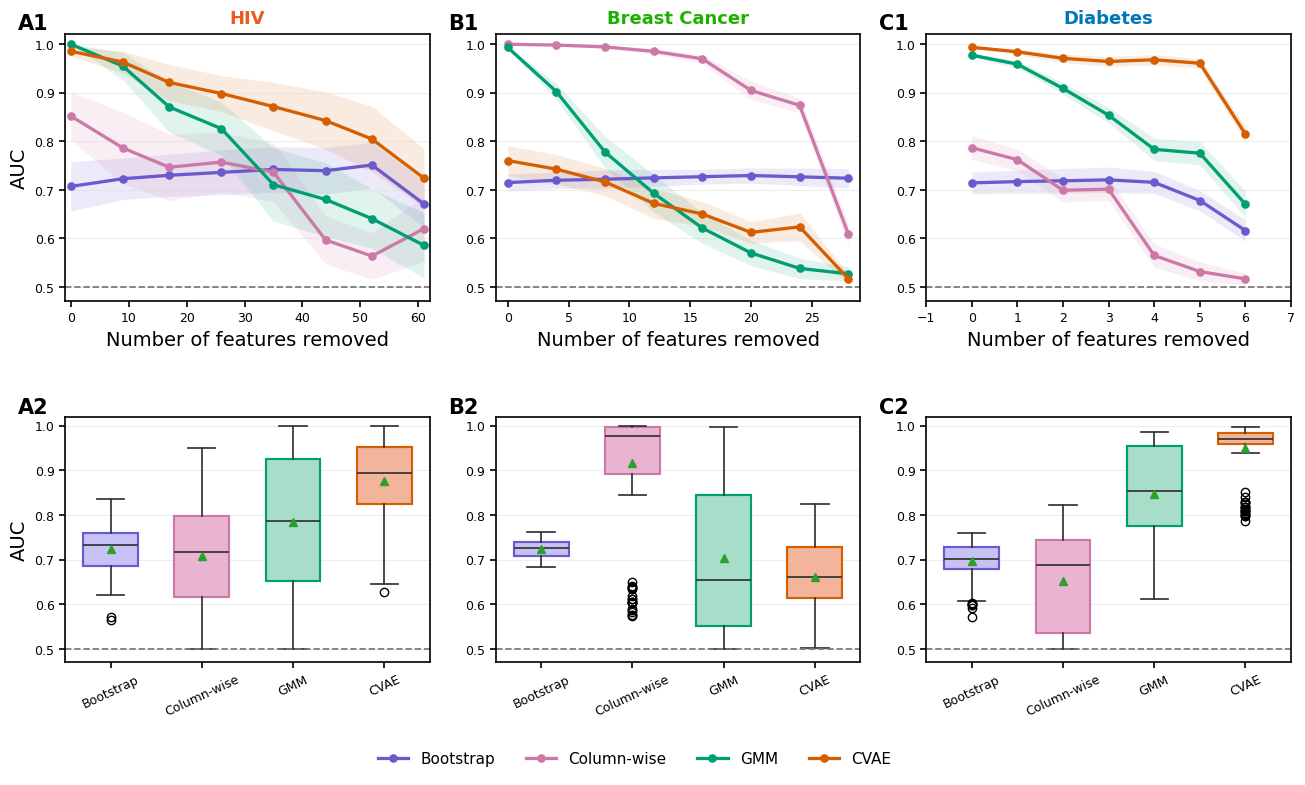

In [113]:
def _flat_values(series):
    vals = []
    for item in series:
        vals.extend(item if isinstance(item, (list, tuple, np.ndarray)) else [item])
    return np.asarray(vals, dtype=float)


def plot_figure6_ablation_all_datasets(ablation_df):
    fig = plt.figure(figsize=(13.4, 8.6), constrained_layout=False)
    gs = fig.add_gridspec(
        2, len(DATASET_ORDER),
        height_ratios=[1.25, 1.15]
    )
    curve_axes = [fig.add_subplot(gs[0, i]) for i in range(len(DATASET_ORDER))]
    box_axes = [fig.add_subplot(gs[1, i], sharey=curve_axes[0]) for i in range(len(DATASET_ORDER))]

    legend_handles = []
    for panel_idx, (ax_curve, ax_box, ds) in enumerate(zip(curve_axes, box_axes, DATASET_ORDER)):
        sub = ablation_df[ablation_df["dataset"] == ds]
        box_values, box_labels = [], []
        if sub.empty:
            ax_curve.set_visible(False)
            ax_box.set_visible(False)
            continue

        for method in METHOD_ORDER:
            m = sub[sub["method"] == method].sort_values("n_features_removed")
            if m.empty:
                continue
            n_removed = m["n_features_removed"]
            line, = ax_curve.plot(n_removed, m["auc_mean"], color=METHOD_COLORS[method], marker="o",  linewidth=2.35, markersize=5.2, label=method)
            ax_curve.fill_between(n_removed, m["auc_mean"] - m["auc_sd"], m["auc_mean"] + m["auc_sd"], color=METHOD_COLORS[method], alpha=0.12, linewidth=0)
            if panel_idx == 0:
                legend_handles.append(line)
            box_values.append(_flat_values(m["auc_values"]))
            box_labels.append(method)

        ax_curve.axhline(0.5, color="#777777", linestyle="--", linewidth=1.25)
        ax_curve.set_title(ds, color=DATASET_COLORS[ds], weight="semibold", pad=8, fontsize=13)
        col_letter = chr(ord("A") + panel_idx)

        ax_curve.text(
            -0.13, 1.08, f"{col_letter}1",
            transform=ax_curve.transAxes,
            fontsize=15,
            weight="bold",
            va="top",
            ha="left"
        )
        max_removed = int(sub["n_features_removed"].max())
        ax_curve.set_xlim(-1, max_removed + 1)
        ax_curve.set_xlabel("Number of features removed")
        clean_axis(ax_curve, grid_axis="y")

        for spine in ax_curve.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.2)

        ax_curve.tick_params(labelsize=9.0, width=1.2, length=4)

        bp = ax_box.boxplot(box_values, tick_labels=box_labels, patch_artist=True, showmeans=True, widths=0.60)
        for patch, method in zip(bp["boxes"], box_labels):
            patch.set_facecolor(METHOD_PASTELS[method])
            patch.set_edgecolor(METHOD_COLORS[method])
            patch.set_linewidth(1.55)
        for key in ["whiskers", "caps", "medians", "means"]:
            for artist in bp.get(key, []):
                artist.set_color(NEUTRAL)
                artist.set_linewidth(1.25)
        ax_box.axhline(0.5, color="#777777", linestyle="--", linewidth=1.25)
        ax_box.tick_params(axis="x", rotation=25, labelsize=9.0, width=1.4, length=5)
        ax_box.text(
            -0.13, 1.08, f"{col_letter}2",
            transform=ax_box.transAxes,
            fontsize=15,
            weight="bold",
            va="top",
            ha="left"
        )


        clean_axis(ax_box, grid_axis="y")

        for spine in ax_box.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.2)

        ax_box.tick_params(labelsize=9.0, width=1.2, length=4)
    curve_axes[0].set_ylabel("AUC")
    box_axes[0].set_ylabel("AUC")
    for ax in curve_axes[1:] + box_axes[1:]:
        ax.set_ylabel("") 
        ax.tick_params(labelleft=True) 

    y_values = []
    for _, row in ablation_df.iterrows():
        y_values.extend([row["auc_mean"] - row["auc_sd"], row["auc_mean"] + row["auc_sd"]])
        y_values.extend(row.get("auc_values", []))
    y_min = max(0.45, np.nanmin(y_values) - 0.03)
    y_max = min(1.02, np.nanmax(y_values) + 0.03)
    for ax in curve_axes + box_axes:
        if ax.get_visible():
            ax.set_ylim(y_min, y_max)

    handles = legend_handles[:len(METHOD_ORDER)]
    fig.legend(handles, [h.get_label() for h in handles], loc="lower center",
               bbox_to_anchor=(0.5, 0.01), ncol=len(handles), frameon=True,
               facecolor="white", edgecolor="black", framealpha=0, borderpad=0.55)
    # fig.suptitle("Reverse feature ablation", y=0.98, fontsize=15, weight="semibold")

    fig.subplots_adjust(left=0.075, right=0.99, top=0.88, bottom=0.15, wspace=0.18, hspace=0.45)
    return fig


ablation_df = get_reverse_ablation(force=False)
fig6_ac = plot_figure6_ablation_all_datasets(ablation_df)


## Export Helpers

Exports are intentionally explicit so we do not overwrite manuscript files by accident.


In [48]:
EXPORT_DIR = repo_root / "data_synthesis" / "notebooks" / "revision_exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Uncomment after running the corresponding figure cells.
# fig2_6.savefig(EXPORT_DIR / "figure2_six_panel_revision.png", dpi=300, bbox_inches="tight")
# fig2_9.savefig(EXPORT_DIR / "figure2_nine_panel_revision.png", dpi=300, bbox_inches="tight")
# fig4_result.fig.savefig(EXPORT_DIR / "figure_4_edge_status_matrices.png", dpi=300, bbox_inches="tight")
# fig5_noise.savefig(EXPORT_DIR / "figure5_noise_revision.png", dpi=300, bbox_inches="tight")
# fig6_ac.savefig(EXPORT_DIR / "figure6_ablation_all_datasets_revision.png", dpi=300, bbox_inches="tight")

SCHEMATIC_PPTX = EXPORT_DIR / "schematic_workflow_editable.pptx"
SCHEMATIC_PPTX


WindowsPath('c:/Users/tonyt/Desktop/distinguishable_data/data_synthesis/notebooks/revision_exports/schematic_workflow_editable.pptx')